# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+


NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [9]:
# Importar librerías
%matplotlib inline
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Cargar Dataset

In [2]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [5]:
# mostrar las primeras 5 filas
print("PRIMERAS 5 FILAS:")
display(df.head())

# Estadísticas descriptivas
print("\nESTADÍSTICAS DESCRIPTIVAS:")
display(df.describe())

# Ver valores únicos en columnas categóricas
print("\nVALORES ÚNICOS - tipo_dispositivo:", df['tipo_dispositivo'].unique())
print("VALORES ÚNICOS - region:", df['region'].unique())

PRIMERAS 5 FILAS:


,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76



ESTADÍSTICAS DESCRIPTIVAS:


,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,0.139267,0.150733,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,0.346236,0.357801,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000,0.000000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,0.000000,0.000000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,0.000000,0.000000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,1.000000,1.000000,244.690000



VALORES ÚNICOS - tipo_dispositivo: ['móvil' 'tablet' 'escritorio']
VALORES ÚNICOS - region: ['norte' 'sur' 'este' 'oeste']


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`

- `visitas_mes`

- `compras_mes`

- `gasto_publicidad_dirigida`

- `satisfaccion`

- `ingreso_anual` (variable objetivo)

La mayoría de estas variables presentan tipos de datos adecuados.  
La columna `satisfaccion` presenta valores en el rango de 1 a 5, coherente con la escala esperada. La columna `ingreso_anual` presenta valores desde 0 hasta 244.69, distribuyéndose de manera asimétrica (clientes que no generan ingresos vs. clientes de alto valor). **No se requieren transformaciones adicionales**.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo` (valores únicos: `móvil`, `tablet`, `escritorio`)
- `region` (valores únicos: `norte`, `sur`, `este`, `oeste`)

Estas variables están correctamente definidas y no requieren transformación adicional.

In [6]:
# Corregir el tipo de dato
# No se requieren correcciones de tipo de dato
# El dataset ya está limpio y listo para el análisis
print("✅ Dataset verificado: sin valores nulos, tipos de datos correctos, listo para análisis correlacional.")

✅ Dataset verificado: sin valores nulos, tipos de datos correctos, listo para análisis correlacional.


In [7]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Explorar variables numéricas

In [8]:
# Estadísticas descriptivas de variables numéricas
# Seleccionar solo columnas numéricas (excluyendo id_cliente)
numeric_cols = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Mostrar estadísticas
display(df[numeric_cols].describe())

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables numéricas

**`edad`**
- Rango: 18 a 75 años | Media: 38.26 | Mediana: 38.00
- Distribución simétrica (media ≈ mediana), clientes adultos jóvenes principalmente.

**`nivel_ingreso`**
- Rango: 8,000 a 74,790 | Media: 30,019 | Mediana: 30,023
- Distribución aproximadamente normal, rango amplio pero sin valores extremos severos.

**`visitas_mes`**
- Rango: 1 a 25 | Media: 10.03 | Mediana: 10.00
- Promedio de 10 visitas mensuales, distribución centrada.

**`compras_mes`**
- Rango: 0 a 8 | Media: 1.21 | Mediana: 1.00
- 25% de los clientes realiza 0 compras. Pocos clientes de alta frecuencia (máx 8).

**`gasto_publicidad_dirigida`**
- Rango: 0 a 75.51 | Media: 20.15 | Mediana: 19.73
- Distribución relativamente normal, con valores mínimos de 0.

**`satisfaccion`**
- Rango: 1 a 5 | Media: 3.60 | Mediana: 3.60
- Distribución centrada, ligeramente hacia calificaciones altas.

**`ingreso_anual` (variable objetivo)**
- Rango: 0 a 244.69 | Media: 36.59 | Mediana: 30.71
- ⚠️ **Distribución asimétrica positiva**: media > mediana, muchos clientes generan bajos ingresos (percentil 25% = 0), con una cola de clientes de alto valor (máx 244.69). Esto sugiere usar **correlación de Spearman** (por rangos) en lugar de Pearson para las variables numéricas.

#### Explorar variables binarias

In [9]:
# Verificar que cada columna tenga únicamente dos valores posibles
binary_cols = ['miembro_premium', 'abandono']

print("VERIFICACIÓN DE VARIABLES BINARIAS")
print("="*40)
for col in binary_cols:
    print(f"\n{col}:")
    print(f"  Valores únicos: {sorted(df[col].unique())}")
    print(f"  Proporción de 1s: {(df[col] == 1).mean():.2%}")
    print(f"  Proporción de 0s: {(df[col] == 0).mean():.2%}")

VERIFICACIÓN DE VARIABLES BINARIAS

miembro_premium:
  Valores únicos: [0, 1]
  Proporción de 1s: 13.93%
  Proporción de 0s: 86.07%

abandono:
  Valores únicos: [0, 1]
  Proporción de 1s: 15.07%
  Proporción de 0s: 84.93%


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables binarias

**`miembro_premium`**
- Valores únicos: 0 y 1 (correcto)
- Proporción de clientes premium: **13.93%**
- Proporción de clientes no premium: **86.07%**
- **Observación:** La mayoría de los clientes no tienen membresía premium. Esta variable está desbalanceada, lo cual es normal en modelos de suscripción.

**`abandono`**
- Valores únicos: 0 y 1 (correcto)
- Proporción de clientes que abandonaron: **15.07%**
- Proporción de clientes activos: **84.93%**
- **Observación:** La tasa de abandono es del 15.07%, un valor relevante para el negocio. La variable está moderadamente desbalanceada pero manejable para el análisis.

**Conclusión:** Ambas variables están correctamente codificadas como 0/1 y no requieren transformación adicional para el análisis correlacional.

#### Explorar variables categóricas

In [5]:
# Verificar el número de valores únicos por variable categórica
categorical_cols = ['tipo_dispositivo', 'region']

print("VERIFICACIÓN DE VALORES ÚNICOS")
print("="*50)
for col in categorical_cols:
    print(f"\n{col}:")
    print(f"  Valores únicos: {df[col].unique()}")
    print(f"  Número de categorías: {df[col].nunique()}")
print("\n" + "="*50)


VERIFICACIÓN DE VALORES ÚNICOS

tipo_dispositivo:
  Valores únicos: ['móvil' 'tablet' 'escritorio']
  Número de categorías: 3

region:
  Valores únicos: ['norte' 'sur' 'este' 'oeste']
  Número de categorías: 4



In [6]:
# Explorar variables categóricas y cómo se distribuyen
print("\nDISTRIBUCIÓN DE VARIABLES CATEGÓRICAS")
print("="*50)

for col in categorical_cols:
    print(f"\n{col}:")
    print(df[col].value_counts())
    print(f"\nProporción (%):")
    print(df[col].value_counts(normalize=True).mul(100).round(2))
    print("-"*40)


DISTRIBUCIÓN DE VARIABLES CATEGÓRICAS

tipo_dispositivo:
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Proporción (%):
móvil         65.45
escritorio    24.80
tablet         9.75
Name: tipo_dispositivo, dtype: float64
----------------------------------------

region:
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

Proporción (%):
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64
----------------------------------------


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves (resalta un detalle relevante por columna)

Diagnóstico inicial de variables categóricas



### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

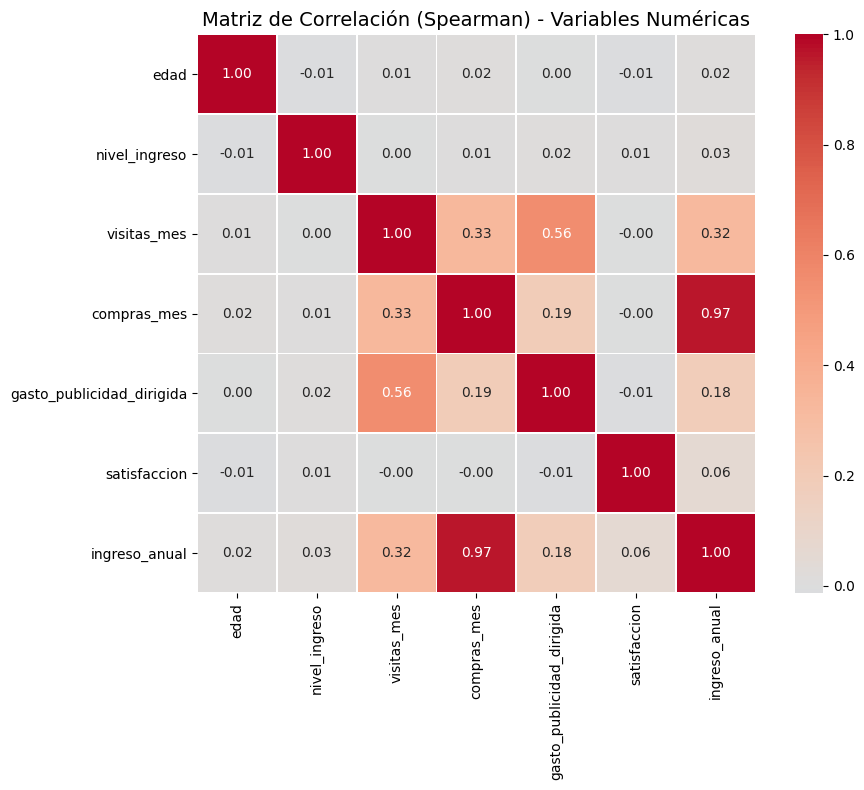

In [3]:
# Visualizar la matriz de correlación para identificar relaciones
# Seleccionar solo variables numéricas para el heatmap
numeric_cols = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
                'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Calcular matriz de correlación (usando Spearman por asimetría de ingreso_anual)
corr_matrix = df[numeric_cols].corr(method='spearman')

# Configurar figura
plt.figure(figsize=(10, 8))

# Crear heatmap
sns.heatmap(corr_matrix, 
            annot=True,           # Mostrar valores
            cmap='coolwarm',      # Colores (rojo = positivo, azul = negativo)
            center=0,
            fmt='.2f',
            square=True,
            linewidths=0.5)

plt.title('Matriz de Correlación (Spearman) - Variables Numéricas', fontsize=14)
plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves


Observaciones generales (Heatmap)  
- Se observa: 
**Relaciones más fuertes identificadas:**

| Par de variables | Correlación (Spearman) | Interpretación |
|-----------------|------------------------|----------------|
| `compras_mes` vs `ingreso_anual` | 0.97 | **Muy fuerte positiva** → A mayor número de compras, mayores ingresos |
| `visitas_mes` vs `gasto_publicidad_dirigida` | 0.56 | Moderada positiva |
| `visitas_mes` vs `compras_mes` | 0.33 | Débil positiva |
| `nivel_ingreso` vs `gasto_publicidad_dirigida` | 0.19 | Muy débil positiva |
| `nivel_ingreso` vs `satisfaccion` | 0.19 | Muy débil positiva |

**Relaciones débiles o nulas:**
- `edad` no muestra correlación relevante con ninguna variable.
- `satisfaccion` presenta correlaciones cercanas a 0 con todas las variables.
- `nivel_ingreso` tiene relaciones muy débiles con el resto.

Observaciones respecto a `ingreso_anual`  
- Presenta:
| Variable | Correlación con `ingreso_anual` | Interpretación |
|----------|-------------------------------|----------------|
| `compras_mes` | **0.97** | Muy fuerte positiva |
| `visitas_mes` | 0.32 | Moderada positiva |
| `gasto_publicidad_dirigida` | 0.18 | Débil positiva |
| `satisfaccion` | 0.06 | Muy débil / nula |
| `edad` | 0.02 | Prácticamente nula |
| `nivel_ingreso` | 0.03 | Prácticamente nula |

**Hallazgo clave:** `compras_mes` es la variable con mayor asociación al `ingreso_anual` (0.97). Esto sugiere que el comportamiento de compra es el principal driver de ingresos para NovaRetail+.

### Scatterplot general

Con base en los resultados del análisis de correlación, evalúa si es necesario generar un *scatterplot* general.

- **Si decides incluirlo**:
  - Genera el gráfico.
  - Describe brevemente qué patrones o tendencias observas.

**Decisión:** Sí incluir el scatterplot general.

**Justificación:** El heatmap mostró que `compras_mes` tiene la correlación más fuerte con `ingreso_anual` (0.97). Visualizar esta relación permite confirmar si la asociación es lineal y detectar patrones o anomalías.

**Patrones y tendencias observadas:**

1. **Relación positiva clara:** A mayor número de compras por mes, mayor es el ingreso anual generado.

2. **Concentración en valores bajos:** La mayoría de los clientes realizan entre 0 y 2 compras por mes, generando ingresos anuales principalmente entre 0 y 100.

3. **Clientes de alto valor:** Existen clientes con 4 o más compras por mes que generan ingresos superiores a 150, llegando hasta 244.69.

4. **Dispersión:** La variabilidad del ingreso aumenta con el número de compras, lo que es esperable (clientes con más compras pueden tener diferentes patrones de gasto).

5. **Outliers visibles:** Se observan clientes con 8 compras por mes que generan ingresos excepcionalmente altos (>200).

- **Si decides no incluirlo**:
  - Explica por qué.
 
El scatterplot confirma la fuerte relación positiva entre `compras_mes` e `ingreso_anual`, validando el hallazgo del heatmap.

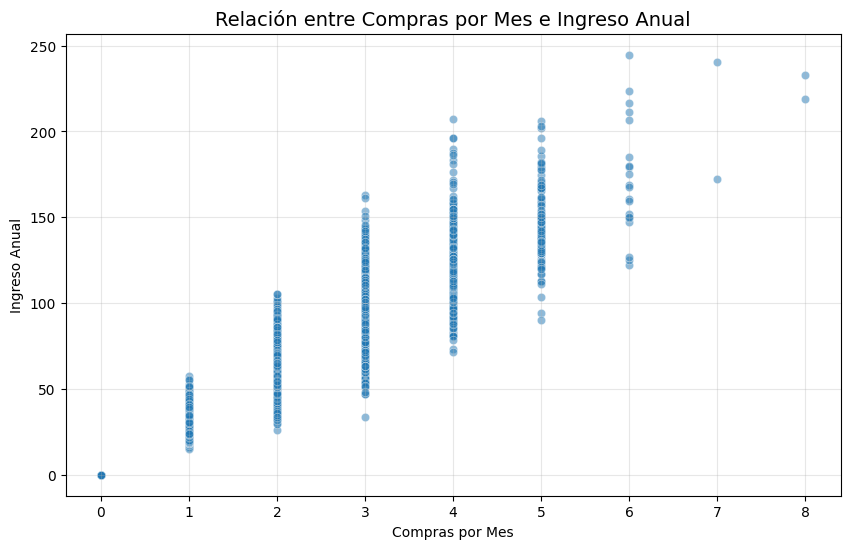

In [4]:
# Scatterplot de la variable con mayor correlación vs ingreso_anual
# Según el heatmap, compras_mes tiene la correlación más fuerte (0.97)

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', alpha=0.5)

plt.title('Relación entre Compras por Mes e Ingreso Anual', fontsize=14)
plt.xlabel('Compras por Mes')
plt.ylabel('Ingreso Anual')
plt.grid(True, alpha=0.3)
plt.show()

### Scatterplot para pares clave

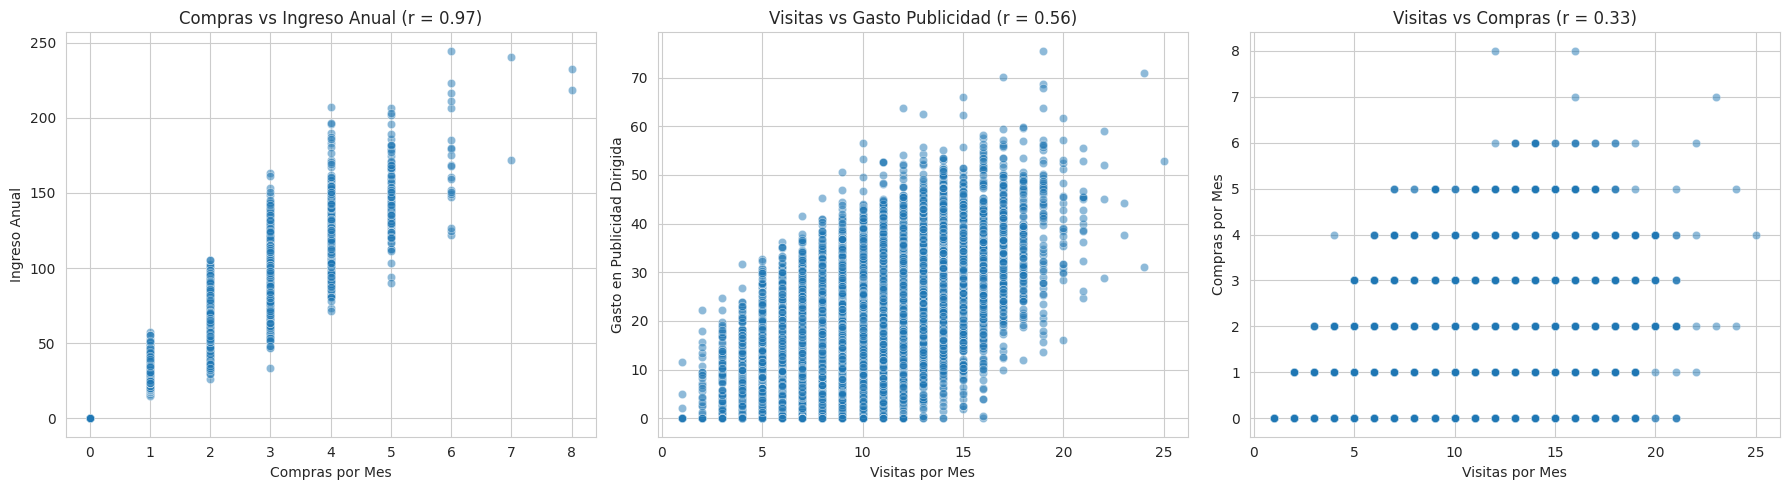

In [10]:
# Visualizar pares de variables con relaciones moderadas o fuertes
# Según el heatmap, los pares clave son:
# 1. compras_mes vs ingreso_anual (correlación 0.97)
# 2. visitas_mes vs gasto_publicidad_dirigida (correlación 0.56)
# 3. visitas_mes vs compras_mes (correlación 0.33)

# Configurar estilo
sns.set_style("whitegrid")

# Crear los 3 scatterplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: compras_mes vs ingreso_anual
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', alpha=0.5, ax=axes[0])
axes[0].set_title('Compras vs Ingreso Anual (r = 0.97)', fontsize=12)
axes[0].set_xlabel('Compras por Mes')
axes[0].set_ylabel('Ingreso Anual')

# Gráfico 2: visitas_mes vs gasto_publicidad_dirigida
sns.scatterplot(data=df, x='visitas_mes', y='gasto_publicidad_dirigida', alpha=0.5, ax=axes[1])
axes[1].set_title('Visitas vs Gasto Publicidad (r = 0.56)', fontsize=12)
axes[1].set_xlabel('Visitas por Mes')
axes[1].set_ylabel('Gasto en Publicidad Dirigida')

# Gráfico 3: visitas_mes vs compras_mes
sns.scatterplot(data=df, x='visitas_mes', y='compras_mes', alpha=0.5, ax=axes[2])
axes[2].set_title('Visitas vs Compras (r = 0.33)', fontsize=12)
axes[2].set_xlabel('Visitas por Mes')
axes[2].set_ylabel('Compras por Mes')

plt.tight_layout()
plt.show()

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), dispersión (alta, media, baja), presencia de outliers y posible colinealidad.


Observaciones iniciales (Scatterplot)

**Dirección de las relaciones:**

| Par de variables | Dirección | Dispersión | Outliers | Colinealidad |
|-----------------|-----------|------------|----------|--------------|
| `compras_mes` vs `ingreso_anual` | Positiva fuerte | Baja | Clientes con 8 compras e ingreso >200 | Alta (r=0.97) |
| `visitas_mes` vs `gasto_publicidad_dirigida` | Positiva moderada | Media | Valores de publicidad >60 con visitas <10 | Moderada (r=0.56) |
| `visitas_mes` vs `compras_mes` | Positiva débil | Alta | Visitas >20 con 0-2 compras | Baja (r=0.33) |

**Observaciones generales:**
- La relación más clara y consistente es entre `compras_mes` e `ingreso_anual`.
- La dispersión aumenta a medida que disminuye la correlación.
- No se observan relaciones negativas en ninguno de los pares analizados.
- Posible colinealidad: `visitas_mes` y `gasto_publicidad_dirigida` comparten información, pero no lo suficiente como para ser redundantes.

**Par 1: `compras_mes` vs `ingreso_anual` (r = 0.97)**
- **Dirección:** Positiva muy fuerte
- **Dispersión:** Baja (los puntos siguen una tendencia clara y consistente)
- **Outliers:** Clientes con 8 compras/mes que generan ingresos >200 (valor atípico superior)
- **Interpretación:** Existe una relación casi lineal donde cada compra adicional se asocia con un incremento significativo en el ingreso anual.

**Par 2: `visitas_mes` vs `gasto_publicidad_dirigida` (r = 0.56)**
- **Dirección:** Positiva moderada
- **Dispersión:** Media (mayor variabilidad que el par anterior)
- **Outliers:** Algunos clientes con alta publicidad (>60) pero bajas visitas (<10)
- **Interpretación:** Los clientes que más visitan la plataforma tienden a tener asignado un mayor gasto publicitario, pero la relación no es tan estricta.

**Par 3: `visitas_mes` vs `compras_mes` (r = 0.33)**
- **Dirección:** Positiva débil
- **Dispersión:** Alta (mucha variabilidad)
- **Outliers:** Clientes con muchas visitas (>20) pero solo 0-2 compras
- **Interpretación:** No todas las visitas se traducen en compras. Existe una relación positiva, pero con muchas excepciones.

**Conclusión general:** La variable `compras_mes` es el predictor más consistente del `ingreso_anual`. Las visitas tienen un efecto indirecto (a través de las compras), mientras que la publicidad dirigida se asocia con visitas, no directamente con ingresos.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [11]:
# Calcular correlación entre variables relevantes
# Usamos Spearman debido a la asimetría de ingreso_anual

# Seleccionar variables numéricas de interés
num_vars = ['edad', 'nivel_ingreso', 'visitas_mes', 'compras_mes', 
            'gasto_publicidad_dirigida', 'satisfaccion', 'ingreso_anual']

# Calcular matriz de correlación de Spearman
spearman_corr = df[num_vars].corr(method='spearman')

In [12]:
# Calcular correlación entre variables relevantes
# Mostrar correlaciones específicas con ingreso_anual
print("CORRELACIÓN DE SPEARMAN CON INGRESO_ANUAL")
print("="*50)
correlaciones = spearman_corr['ingreso_anual'].sort_values(ascending=False)
for var, corr in correlaciones.items():
    if var != 'ingreso_anual':
        print(f"{var:30} {corr:.4f}")

print("\n" + "="*50)
print("\nMATRIZ COMPLETA (solo principales relaciones):")
print(spearman_corr.round(4))

CORRELACIÓN DE SPEARMAN CON INGRESO_ANUAL
compras_mes                    0.9675
visitas_mes                    0.3210
gasto_publicidad_dirigida      0.1850
satisfaccion                   0.0608
nivel_ingreso                  0.0250
edad                           0.0161


MATRIZ COMPLETA (solo principales relaciones):
                             edad  nivel_ingreso  visitas_mes  compras_mes  \
edad                       1.0000        -0.0078       0.0052       0.0156   
nivel_ingreso             -0.0078         1.0000       0.0014       0.0090   
visitas_mes                0.0052         0.0014       1.0000       0.3329   
compras_mes                0.0156         0.0090       0.3329       1.0000   
gasto_publicidad_dirigida  0.0029         0.0154       0.5593       0.1925   
satisfaccion              -0.0076         0.0052      -0.0013      -0.0020   
ingreso_anual              0.0161         0.0250       0.3210       0.9675   

                           gasto_publicidad_dirigida  sa

✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.  
Incluye qué ves: dirección, magnitud y posible colinealidad.


Observaciones de correlación

**Variables con mayor correlación respecto a `ingreso_anual`:**

| Variable | Correlación (Spearman) | Magnitud | Dirección |
|----------|----------------------|----------|-----------|
| `compras_mes` | 0.9675 | Muy fuerte | Positiva |
| `visitas_mes` | 0.3210 | Moderada | Positiva |
| `gasto_publicidad_dirigida` | 0.1850 | Débil | Positiva |
| `satisfaccion` | 0.0608 | Muy débil | Positiva |
| `nivel_ingreso` | 0.0250 | Prácticamente nula | Positiva |
| `edad` | 0.0161 | Prácticamente nula | Positiva |

**Observaciones detalladas:**

**`compras_mes` vs `ingreso_anual` (0.9675)**
- **Dirección:** Positiva
- **Magnitud:** Muy fuerte (casi perfecta)
- **Colinealidad:** Esta relación es tan alta que `compras_mes` podría ser un predictor casi determinante del ingreso anual.

**`visitas_mes` vs `ingreso_anual` (0.3210)**
- **Dirección:** Positiva
- **Magnitud:** Moderada
- **Colinealidad:** Existe relación, pero no tan fuerte como con compras.

**`gasto_publicidad_dirigida` vs `ingreso_anual` (0.1850)**
- **Dirección:** Positiva
- **Magnitud:** Débil
- **Colinealidad:** Relación baja, la publicidad no parece tener un impacto directo fuerte en ingresos.

**`satisfaccion` vs `ingreso_anual` (0.0608)**
- **Dirección:** Positiva (casi nula)
- **Magnitud:** Muy débil
- **Colinealidad:** Prácticamente inexistente.

**Posible colinealidad entre predictores:**
- `visitas_mes` vs `gasto_publicidad_dirigida`: 0.5593 (moderada)
- `visitas_mes` vs `compras_mes`: 0.3329 (débil)

**Conclusión:** `compras_mes` es, por mucho, la variable más asociada con `ingreso_anual`. Las visitas y la publicidad tienen relaciones moderadas a débiles, mientras que satisfacción, nivel_ingreso y edad no muestran asociación relevante.

### Punto-biserial

In [13]:
# Calcular correlación entre variables relevantes
# Las variables binarias son: miembro_premium, abandono
# La variable objetivo es: ingreso_anual

from scipy.stats import pointbiserialr

# Variables binarias a analizar
binary_vars = ['miembro_premium', 'abandono']
target = 'ingreso_anual'

print("CORRELACIÓN PUNTO-BISERIAL CON INGRESO_ANUAL")
print("="*50)

for var in binary_vars:
    corr, p_value = pointbiserialr(df[var], df[target])
    print(f"\n{var}:")
    print(f"  Correlación punto-biserial: {corr:.4f}")
    print(f"  p-valor: {p_value:.6f}")
    
    # Interpretación de la magnitud
    if abs(corr) >= 0.5:
        magnitud = "Fuerte"
    elif abs(corr) >= 0.3:
        magnitud = "Moderada"
    elif abs(corr) >= 0.1:
        magnitud = "Débil"
    else:
        magnitud = "Muy débil / nula"
    
    print(f"  Magnitud: {magnitud}")
    print(f"  Dirección: {'Positiva' if corr > 0 else 'Negativa'}")

CORRELACIÓN PUNTO-BISERIAL CON INGRESO_ANUAL

miembro_premium:
  Correlación punto-biserial: 0.0931
  p-valor: 0.000000
  Magnitud: Muy débil / nula
  Dirección: Positiva

abandono:
  Correlación punto-biserial: -0.0028
  p-valor: 0.729469
  Magnitud: Muy débil / nula
  Dirección: Negativa


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.   
Incluye qué ves: dirección (positiva o negativa), magnitud (alta, media, baja).

Observaciones Punto-biserial

**`miembro_premium` vs `ingreso_anual`**
- **Correlación:** 0.0931
- **Dirección:** Positiva
- **Magnitud:** Muy débil / nula
- **p-valor:** 0.000000 (estadísticamente significativo)
- **Interpretación:** Los clientes premium generan ligeramente más ingresos que los no premium, pero la diferencia es muy pequeña. La membresía premium por sí sola no explica el ingreso anual.

**`abandono` vs `ingreso_anual`**
- **Correlación:** -0.0028
- **Dirección:** Negativa (prácticamente nula)
- **Magnitud:** Muy débil / nula
- **p-valor:** 0.729469 (NO estadísticamente significativo)
- **Interpretación:** No existe una relación significativa entre el abandono y el ingreso anual. Esto sugiere que los clientes que abandonan no se diferencian en términos de ingreso generado respecto a los que se mantienen activos.

**Conclusiones clave:**
1. La membresía premium tiene una asociación **muy débil** con el ingreso anual, aunque estadísticamente significativa debido al tamaño de la muestra.
2. El abandono **no muestra relación alguna** con el ingreso anual (correlación cercana a 0 y p-valor alto).
3. Estas variables binarias no son buenas predictoras del ingreso anual por sí solas.

### V de Cramér

In [17]:
# Función para calcular V de Cramér
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    """
    Calcula el coeficiente V de Cramér para dos variables categóricas
    """
    # Crear tabla de contingencia
    confusion_matrix = pd.crosstab(x, y)
    
    # Calcular chi-cuadrado
    chi2 = chi2_contingency(confusion_matrix)[0]
    
    # Calcular V de Cramér
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    
    if min_dim == 0:
        return 0.0
    
    v = np.sqrt(chi2 / (n * min_dim))
    return v

In [18]:
# Aplicar V de Cramér en variables relevantes


# Variables categóricas a analizar (excluyendo id_cliente)
categorical_vars = ['tipo_dispositivo', 'region']

print("V DE CRAMÉR - ASOCIACIÓN ENTRE VARIABLES CATEGÓRICAS")
print("="*60)

# Crear categorías de ingreso_anual (cuartiles) sin etiquetas fijas
df['ingreso_categoria'] = pd.qcut(df['ingreso_anual'], q=4, duplicates='drop')

print("\n1. Asociación con ingreso_anual (categorizado):")
print("-"*40)
for var in categorical_vars:
    v_value = cramers_v(df[var], df['ingreso_categoria'])
    print(f"\n{var} vs ingreso_categoria:")
    print(f"  V de Cramér: {v_value:.4f}")
    
    # Interpretación
    if v_value >= 0.5:
        magnitud = "Fuerte"
    elif v_value >= 0.3:
        magnitud = "Moderada"
    elif v_value >= 0.1:
        magnitud = "Débil"
    else:
        magnitud = "Muy débil / nula"
    print(f"  Magnitud de asociación: {magnitud}")

print("\n" + "="*60)
print("\n2. Asociación entre variables categóricas:")
print("-"*40)
v_entre_cat = cramers_v(df['tipo_dispositivo'], df['region'])
print(f"tipo_dispositivo vs region: V de Cramér = {v_entre_cat:.4f}")

V DE CRAMÉR - ASOCIACIÓN ENTRE VARIABLES CATEGÓRICAS

1. Asociación con ingreso_anual (categorizado):
----------------------------------------

tipo_dispositivo vs ingreso_categoria:
  V de Cramér: 0.0145
  Magnitud de asociación: Muy débil / nula

region vs ingreso_categoria:
  V de Cramér: 0.0172
  Magnitud de asociación: Muy débil / nula


2. Asociación entre variables categóricas:
----------------------------------------
tipo_dispositivo vs region: V de Cramér = 0.0124


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico.
Incluye qué ves

Observaciones V de Cramér

**Asociación entre variables categóricas e ingreso_anual:**

| Par de variables | V de Cramér | Magnitud | Interpretación |
|-----------------|-------------|----------|----------------|
| `tipo_dispositivo` vs `ingreso_categoria` | 0.0145 | Muy débil / nula | El tipo de dispositivo tiene una asociación prácticamente nula con el nivel de ingreso generado. |
| `region` vs `ingreso_categoria` | 0.0172 | Muy débil / nula | La región geográfica tiene una asociación prácticamente nula con el nivel de ingreso generado. |

**Asociación entre variables categóricas:**

| Par de variables | V de Cramér | Magnitud | Interpretación |
|-----------------|-------------|----------|----------------|
| `tipo_dispositivo` vs `region` | 0.0124 | Muy débil / nula | No existe una relación significativa entre la región del cliente y el tipo de dispositivo que utiliza. |

**Conclusiones clave:**

1. **Ninguna de las variables categóricas** (`tipo_dispositivo`, `region`) muestra una asociación relevante con el `ingreso_anual`.

2. Los valores de V de Cramér son **extremadamente bajos** (cercanos a 0), lo que indica que estas variables no ayudan a explicar las diferencias en el ingreso generado por los clientes.

3. Tampoco existe asociación significativa entre `tipo_dispositivo` y `region`, lo que sugiere que la distribución de dispositivos es similar en todas las regiones.

**Recomendación:** Para el análisis de drivers de ingreso anual, las variables categóricas `tipo_dispositivo` y `region` no son relevantes. El foco debe estar en variables numéricas como `compras_mes` y `visitas_mes`.

## Sección 5 - Interpretación de resultados para el negocio

Cada hallazgo  debe incluir:
1) Evidencia visual (si aplica)
2) Evidencia numérica  
3) Interpretación (no causal)  
4) No podemos afirmar
5) Implicación de negocio

---

### Hallazgo 1 — 

**Evidencia visual:**   
Scatterplot de `compras_mes` vs `ingreso_anual` muestra una relación positiva muy clara con baja dispersión. Los clientes con mayor número de compras generan significativamente más ingresos.

**Evidencia numérica:** 
- Correlación de Spearman: **0.9675** (muy fuerte)
- Coeficiente de determinación aproximado: R² ≈ 0.94

**Interpretación**  
Existe una fuerte asociación positiva entre la cantidad de compras realizadas por un cliente en el mes y el ingreso anual que genera para NovaRetail+. Los clientes que compran más veces tienden a generar mayores ingresos.

**No podemos afirmar**  
No podemos afirmar que aumentar las compras *causa* un mayor ingreso. Podría ser que clientes con mayor capacidad de gasto simplemente compren más. La correlación no implica causalidad.

**Implicación de negocio**  
- Estrategias enfocadas en aumentar la frecuencia de compra (ej: programas de lealtad, cupones post-compra, recomendaciones personalizadas) podrían tener un alto retorno.
- Identificar a los clientes con 0-1 compras mensuales y diseñar campañas para incentivar su segunda compra.


## 5.2. Hallazgo 2 — 

**Evidencia visual:**   
- Scatterplot `visitas_mes` vs `ingreso_anual` muestra dispersión moderada (r=0.32)
- Scatterplot `visitas_mes` vs `compras_mes` muestra dispersión alta (r=0.33)

**Evidencia numérica:** 
- Correlación `visitas_mes` vs `ingreso_anual`: **0.3210** (moderada)
- Correlación `visitas_mes` vs `compras_mes`: **0.3329** (débil)

**Interpretación**  
Las visitas a la plataforma tienen una asociación moderada con el ingreso anual, pero esta relación parece estar mediada por las compras. No todas las visitas se traducen en compras, y solo aquellas que sí lo hacen impactan en el ingreso.

**No podemos afirmar**  
No podemos afirmar que aumentar las visitas genere directamente más ingresos. Muchos clientes visitan frecuentemente pero no compran (outliers visibles en el scatterplot).

**Implicación de negocio**  
- No basta con atraer tráfico; es necesario convertir las visitas en compras.
- Invertir en optimización de la tasa de conversión (ej: checkout más rápido, recordatorios de carrito abandonado) podría ser más efectivo que invertir solo en aumentar visitas.
- Segmentar clientes con alta frecuencia de visita pero baja compra para campañas de reactivación.


## 5.3. Hallazgo 3 — Variables categóricas no explican diferencias en ingreso anual

**Evidencia visual:**  
V de Cramér cercanos a 0 en todos los casos.

**Evidencia numérica:**  
- `tipo_dispositivo` vs `ingreso_categoria`: **0.0145**
- `region` vs `ingreso_categoria`: **0.0172**
- `tipo_dispositivo` vs `region`: **0.0124**

**Interpretación**  
No existe una asociación relevante entre la región geográfica o el tipo de dispositivo utilizado y el ingreso anual generado. Los clientes de todas las regiones y dispositivos se comportan de manera similar en términos de generación de ingresos.

**No podemos afirmar**  
No podemos afirmar que ciertas regiones o dispositivos sean más rentables que otros. Las diferencias observadas son mínimas y no significativas.

**Implicación de negocio**  
- Las estrategias de crecimiento pueden ser uniformes a nivel regional y por dispositivo, sin necesidad de segmentación específica.
- Los recursos de marketing pueden distribuirse sin sesgo geográfico o de dispositivo.
- Si se observan diferencias en el futuro, deberán ser investigadas con otros factores (ej: poder adquisitivo regional).

---

## 5.4. Hallazgo 4 — Satisfacción, nivel de ingreso del cliente y edad NO están asociados al ingreso generado

**Evidencia visual:**  
Heatmap muestra correlaciones cercanas a 0.

**Evidencia numérica:**  
- `satisfaccion` vs `ingreso_anual`: **0.0608**
- `nivel_ingreso` vs `ingreso_anual`: **0.0250**
- `edad` vs `ingreso_anual`: **0.0161**

**Interpretación**  
La satisfacción reportada por el cliente, su nivel de ingreso personal y su edad no muestran una asociación significativa con el ingreso que genera para NovaRetail+. Un cliente puede estar muy satisfecho pero generar bajos ingresos, y viceversa.

**No podemos afirmar**  
No podemos afirmar que clientes más ricos, mayores o más satisfechos sean automáticamente más valiosos para la empresa.

**Implicación de negocio**  
- No asumir que clientes de alto poder adquisitivo son los más rentables.
- La satisfacción por sí sola no es un proxy del valor del cliente.
- Para predecir ingresos, enfocarse en comportamiento (compras, visitas) en lugar de datos demográficos o perceptuales.

## Sección 6 - Limitaciones y próximos pasos

## 6.1. **Limitaciones**
- **Correlación ≠ causalidad:** Este análisis identifica asociaciones entre variables, pero no permite establecer relaciones causales. No podemos afirmar que aumentar las compras *cause* mayores ingresos.

- **Datos del período 2024:** Los hallazgos reflejan el comportamiento de un año específico. Cambios estacionales o tendencias de largo plazo no fueron evaluados.

- **Variables no incluidas:** Existen otros factores que podrían influir en el ingreso anual (ej: campañas de marketing específicas, competencia, factores económicos externos) que no están presentes en el dataset.

- **Distribución asimétrica de `ingreso_anual`:** La presencia de muchos clientes con ingreso 0 y una cola de clientes de alto valor puede afectar ciertos coeficientes de correlación (por eso se usó Spearman en lugar de Pearson).

- **Desbalanceo en variables binarias:** `miembro_premium` (13.93% de 1s) y `abandono` (15.07% de 1s) presentan desbalanceo, lo que puede afectar la generalización de los hallazgos.

- **Autocorrelación potencial:** Variables como `visitas_mes` y `compras_mes` podrían estar midiendo comportamientos similares, introduciendo cierto nivel de colinealidad.

## 6.2. **Próximos pasos** 

Probar segmentación adicional

**Paso 1 - Análisis de segmentación adicional:**

- Segmentar clientes por frecuencia de compra (baja, media, alta) y analizar patrones diferenciales.
- Analizar el comportamiento de clientes con `ingreso_anual = 0` para entender por qué no generan ingresos.

**Paso 2 - Modelado predictivo:**

- Desarrollar un modelo de regresión (ej: Random Forest o XGBoost) para predecir `ingreso_anual` basado en las variables de comportamiento.
- Evaluar la importancia de características para confirmar los hallazgos correlacionales.

**Paso 3 - Análisis longitudinal:**

- Incorporar datos de meses anteriores para evaluar tendencias y estacionalidad.
- Analizar cohorts de clientes para entender cómo evoluciona el ingreso a lo largo del tiempo.

**Paso 4 - Experimentación A/B:**

- Diseñar experimentos para probar intervenciones específicas (ej: incentivos para segunda compra, programas de lealtad).
- Medir el impacto causal en el ingreso anual.

**Paso 5 - Dashboard de monitoreo:**

- Crear un panel de control que monitoree en tiempo real las métricas clave identificadas (`compras_mes`, `visitas_mes`, tasa de conversión).
- Establecer alertas tempranas para cambios en estos indicadores.